In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path('../src').resolve()))


In [2]:
import pathlib
import numpy as np
import duckdb
import pandas as pd
import ipywidgets as w
from IPython.display import display, HTML
from dotenv import load_dotenv

from irp.features.metrics import compute_metrics

_ROOT = pathlib.Path().resolve()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent

load_dotenv()
con = duckdb.connect(str(_ROOT / "data/irp.duckdb"), read_only=True)
con.execute("PRAGMA disable_progress_bar")

fundamentals = {
    t: con.execute(f"SELECT * FROM {t}").df() for t in ("income", "balance", "cashflow")
}
# Restrict prices to tickers that have fundamentals (screener needs both)
prices = con.execute(
    'SELECT ticker, date, open, high, low, close, volume FROM prices '
    'WHERE ticker IN (SELECT DISTINCT "Ticker" FROM income)'
).df()

ticker_info = con.execute("""
    SELECT c.Ticker AS ticker, i.Sector AS sector, i.Industry AS industry
    FROM companies c
    LEFT JOIN industries i ON c.IndustryId = i.IndustryId
""").df()

metrics_cache = {}


def get_metrics(period: str) -> pd.DataFrame:
    if period not in metrics_cache:
        metrics_cache[period] = compute_metrics(
            fundamentals, prices, period, latest=True
        )
    return metrics_cache[period]


_warm = get_metrics("annual")
print(f"Loaded {_warm.shape[0]} tickers, {_warm.shape[1]} metric columns")

Loaded 4420 tickers, 48 metric columns


In [ ]:
metrics_df = pd.concat(metrics_cache.values(), ignore_index=True)
metrics_df

,ticker,period,price,P/E,Earnings Yield,P/B,P/S,P/FCF,EV/EBITDA,EV/Sales,...,Return 1M,Return 3M,Return 6M,Return 1Y,Return YTD,Dist from 52w High,Dist from 52w Low,Volatility (annualized),Market Cap,PEG
0,AY,2020FY,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OPNT,2020FY,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BBW,2020FY,36.2600,2050.539121,0.000488,6.038414,1.580865,0.058015,0.037096,1.501921,...,-0.047544,-0.395264,-0.336626,0.016826,-0.405574,-0.521951,0.024583,0.553102,0.535191,NaN
3,CANG,2020FY,0.4523,-0.000337,-2969.688942,0.090822,NaN,NaN,NaN,NaN,...,-0.035402,-0.616695,-0.763812,-0.777192,-0.679220,-0.835527,0.327951,0.940086,0.114830,NaN
4,MSGN,2020FY,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4415,PETS,2025FY,2.2700,-7.455425,-0.134131,0.549169,0.205986,-118.361949,-1.187514,-0.035101,...,-0.008734,-0.260586,-0.099206,-0.347701,-0.312121,-0.458234,0.418750,0.880202,0.046753,NaN
4416,SKLZ,2024FY,6.8000,-2.593529,-0.385575,0.701306,1.306749,-15.674405,0.274310,-0.268322,...,1.720000,0.868132,0.027190,0.360000,0.541950,-0.453815,1.982456,1.597903,0.121351,NaN
4417,VSBC,2023FY,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4418,PHYT,2024FY,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
prices["date"] = pd.to_datetime(prices["date"])
mask = prices['ticker'] == 'PLNT'
ibm_c = prices[mask].set_index("date").sort_index()['close']
ibm_c


date
2015-08-06    14.067
2015-08-07    16.045
2015-08-10    16.423
2015-08-11    15.280
2015-08-12    14.761
               ...  
2026-04-28    64.460
2026-04-29    64.190
2026-04-30    66.670
2026-05-01    65.380
2026-05-04    63.290
Name: close, Length: 2701, dtype: float64

In [ ]:
ibm_lret = pd.Series(np.log(ibm_c / ibm_c.shift(1))).dropna()

ibm_lret

date
2015-08-07    0.131566
2015-08-10    0.023286
2015-08-11   -0.072138
2015-08-12   -0.034556
2015-08-13    0.100280
                ...   
2026-04-28   -0.032209
2026-04-29   -0.004197
2026-04-30    0.037908
2026-05-01   -0.019539
2026-05-04   -0.032489
Name: close, Length: 2700, dtype: float64

<Axes: >

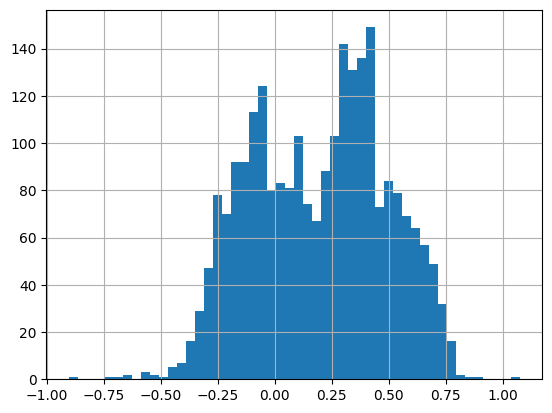

In [ ]:
n = 252
(ibm_lret.rolling(n).sum() * 252 / n).dropna().hist(bins=50)


<Axes: xlabel='date'>

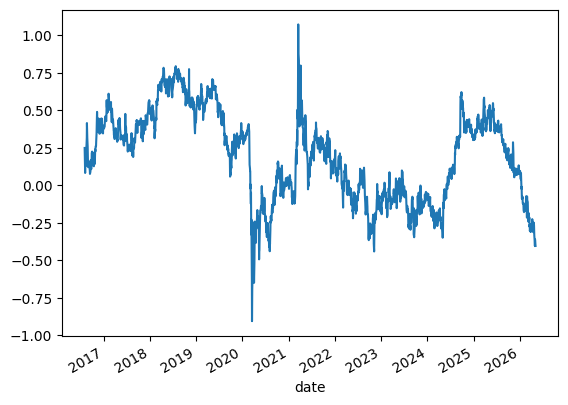

In [ ]:
(ibm_lret.rolling(n).sum() * 252 / n).dropna().plot()

<Axes: xlabel='date'>

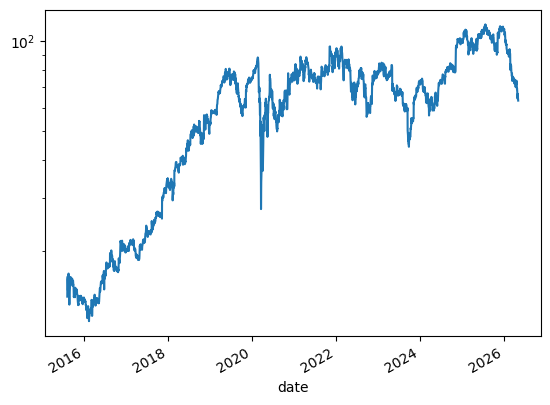

In [ ]:
ibm_c.plot(logy=True)

In [ ]:
n = len(ibm_lret)
r = (ibm_lret.rolling(n).sum() * 252 / n).dropna().values[0]
r

np.float64(0.14036359960108788)

In [ ]:
ibm_c.iloc[0]*(np.exp(r*n/252) )

np.float64(63.290000000000056)

### Long-short pairs

Caveat first: true stock-level inverse correlation between sector peers is rare — macro/sector moves pull them together. Best candidates are disruptor vs. incumbent pairs where one structurally bleeds customers to the other. 


| # | Long | Short | Battle |                                                                                                                                                                             
  |---|------|-------|--------|                                                                                               
  | 1 | AMD | INTC | x86 CPU: AMD wins data center share, Intel loses margins |                                                                                       
  | 2 | NFLX | CMCSA | Cord-cutting: streaming subs rise as cable subs fall |                                                                                                                               
  | 3 | ABNB | MAR | Short-term rentals cannibalize hotel room-nights |
  | 4 | CVNA | AN | Online car retail vs. traditional dealerships |                                                                                                                                         
  | 5 | SPOT | SIRI | Streaming audio displaces satellite radio |                                                             
  | 6 | UBER | LYFT | Ride-share duopoly — promotions shift share zero-sum |                                                                                                                                
  | 7 | SHOP | EBAY | Independent merchant platform vs. captive marketplace |                                                 
  | 8 | TSLA | STLA | EV transition: ICE volume shrinks as EV leader scales |                                                                                                                               
  | 9 | COIN | CME | Crypto spot trading vs. legacy derivatives exchange |                                                    
  | 10 | RKLB | BA | Small-sat launch market: Rocket Lab wins slots Boeing loses |          

Strongest actual inverse signal historically: AMD/INTC and NFLX/CMCSA — both have clean causal mechanism and documented market share transfer. Pairs 6-10 have the economic logic but positive beta noise often swamps it.   

In [4]:
def price_for_ticker(ticker: str, start_date: str, end_date: str) -> pd.Series:
    mask = (
        (prices['ticker'] == ticker)
        & (prices['date'] >= start_date)
        & (prices['date'] <= end_date)
    )
    return prices[mask].set_index("date").sort_index()['close']



<Axes: xlabel='date'>

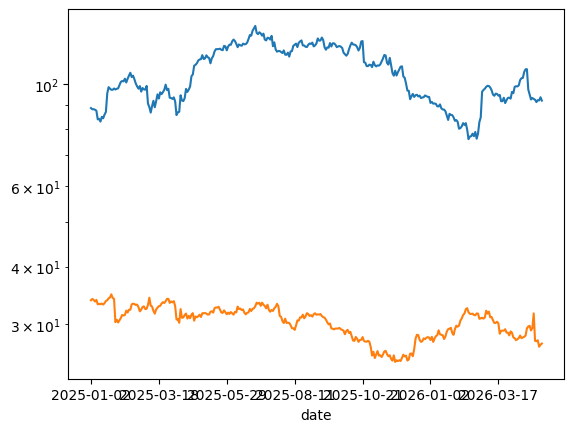

In [15]:
nflx = price_for_ticker("NFLX", "2025-01-01", "2026-05-01")
cmcsa = price_for_ticker("CMCSA", "2025-01-01", "2026-05-01")
nflx.plot(logy=True)
cmcsa.plot(logy=True)

In [22]:
def correlation(p1: pd.Series, p2: pd.Series) -> float:
    return p1.corr(p2)
correlation(nflx, cmcsa)

np.float64(0.034613346390561836)

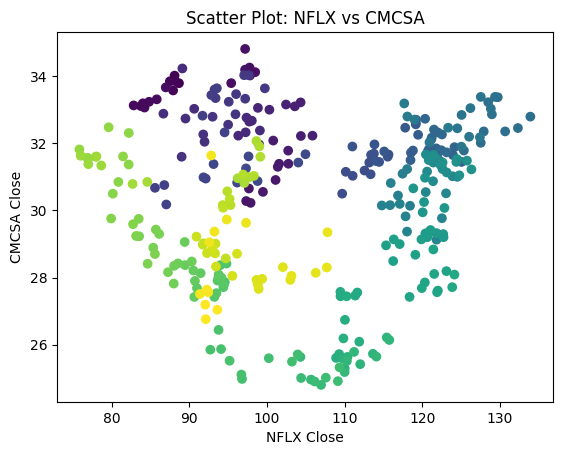

In [16]:
import matplotlib.pyplot as plt

plt.scatter(nflx, cmcsa, c=range(len(nflx)), cmap='viridis')
plt.xlabel('NFLX Close')
plt.ylabel('CMCSA Close')
plt.title('Scatter Plot: NFLX vs CMCSA')
plt.show()